# 01 — EDA and First TDA Inference

This notebook walks through the complete Topological Data Analysis (TDA) pipeline
from scratch, starting with a synthetic phantom (where we know the ground truth)
and ending with an analysis of a real 3-D CT scan.

**What you will see:**
1. Generate a synthetic 3-D phantom — a solid sphere with *N* internal voids
2. Run persistent homology on it and **verify** GUDHI recovers exactly *N* H₂ features
3. Load a real CT volume (Kanzi apple or Open SciVis bonsai)
4. Preprocess: downsample → normalise → optional threshold
5. Run TDA on the real volume; plot H₀, H₁, H₂ persistence diagrams
6. Interpret what H₀, H₁, H₂ features mean biologically
7. Vectorise diagrams into persistence images (input to a future classifier)
8. Side-by-side comparison: phantom vs real CT

**Prerequisite:** activate the project virtual environment before launching Jupyter:
```powershell
.venv\Scripts\Activate.ps1
jupyter lab
```
Then select the **tda-fruit-ct (.venv)** kernel in Jupyter.

---
## Setup

In [1]:
from __future__ import annotations
import warnings
warnings.filterwarnings('ignore')

import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Project modules
from tda_fruit_ct import (
    synthetic,
    data_loader,
    filtration,
    persistence,
    vectorization,
    viz,
)

# Paths
ROOT        = Path('..').resolve()
DATA_DIR    = ROOT / 'data'
FIGURES_DIR = ROOT / 'results' / 'figures'
PHANT_DIR   = DATA_DIR / 'processed' / 'phantoms'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PHANT_DIR.mkdir(parents=True, exist_ok=True)

print('All imports OK')
print(f'Figures will be saved to: {FIGURES_DIR}')

All imports OK
Figures will be saved to: D:\Dev\tda-fruit-ct\results\figures


---
## Section 1 — The synthetic phantom

Before touching real data, we need to **validate the pipeline**. We generate a phantom
whose topology is exactly known, run TDA on it, and confirm that GUDHI recovers the
right answer.

### What is this phantom?

A **solid sphere** (representing fruit flesh) with **N spherical cavities drilled
out** (representing internal browning voids, air pockets, or core breakdown).

The density field is smoothed with a Gaussian so the filtration has a nice gradient:
- `density ≈ 1` deep inside the solid flesh  
- `density ≈ 0` inside the cavities and outside the fruit

For TDA we pass `filtration_field = 1 − density` so the **solid material appears
first** (low filtration value) and the **air voids appear last** (high filtration
value). Each enclosed air void then creates exactly one H₂ (2-sphere) class.

In [2]:
N_CAVITIES = 4
PHANTOM_SHAPE = (64, 64, 64)  # small enough to be instant; increase for smoother results

phantom, n_placed = synthetic.sphere_with_cavities(
    shape=PHANTOM_SHAPE,
    n_cavities=N_CAVITIES,
    outer_radius_frac=0.40,
    cavity_radius_frac=0.075,
    smooth_sigma=1.5,
    rng=np.random.default_rng(42),
)
print(f'Phantom shape : {phantom.shape}')
print(f'dtype         : {phantom.dtype}')
print(f'Density range : [{phantom.min():.3f}, {phantom.max():.3f}]')
print(f'Cavities requested : {N_CAVITIES} | placed : {n_placed}')

# Save for later use
synthetic.save_phantom(
    phantom,
    PHANT_DIR / f'sphere_{n_placed}cav_64.npy',
    metadata={'n_cavities': n_placed, 'shape': list(phantom.shape)},
)

Phantom shape : (64, 64, 64)
dtype         : float32
Density range : [0.000, 1.000]
Cavities requested : 4 | placed : 4


WindowsPath('D:/Dev/tda-fruit-ct/data/processed/phantoms/sphere_4cav_64.npy')

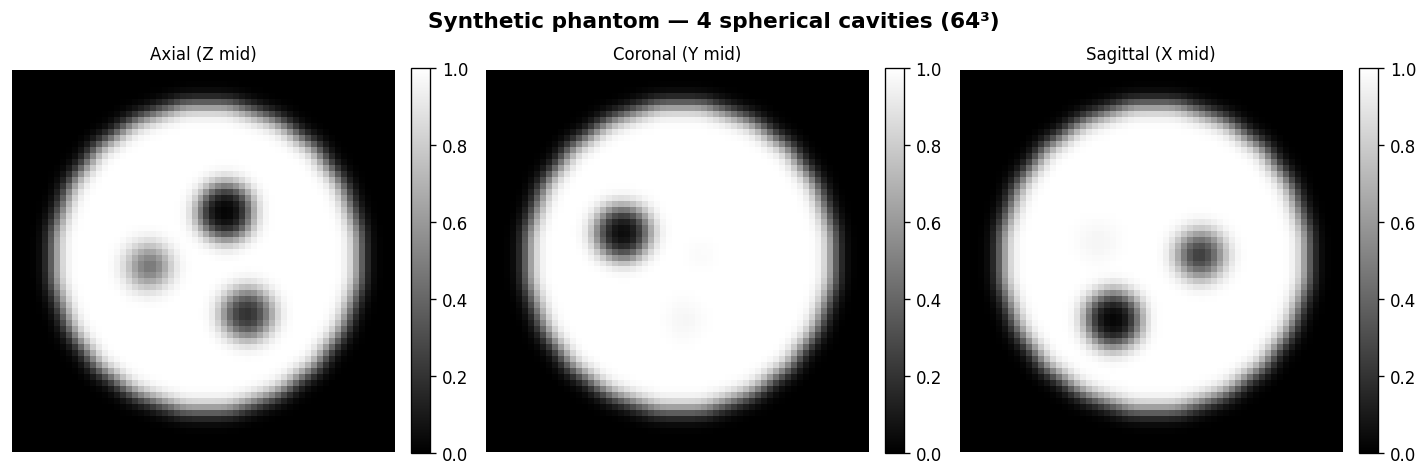

Saved: 01_phantom_slices.png


In [3]:
fig = viz.plot_slices(
    phantom,
    title=f'Synthetic phantom — {n_placed} spherical cavities (64³)',
    save_path=FIGURES_DIR / '01_phantom_slices.png',
)
plt.show(); plt.close(fig)
print('Saved: 01_phantom_slices.png')

---
## Section 2 — TDA on the phantom (pipeline validation)

### What is persistent homology doing?

We sweep a **threshold** *t* from 0 → 1 (low density → high density),
watching which topological features appear and disappear:

| Dimension | Meaning in 3-D CT |
|-----------|-------------------|
| **H₀** | Connected components — separate solid blobs |
| **H₁** | Loops / tunnels through the solid |
| **H₂** | Enclosed cavities (2-spheres surrounding a void) |

Because we use `filtration = 1 − density`:
- **Birth of H₂** ≈ filtration value when the solid shell around a void first closes  
- **Death of H₂** ≈ filtration value when the void itself is 'absorbed' into the sublevel set  
- **Persistence** = death − birth → large for real, deep voids; small for noise

**Expected result:** exactly `n_placed` H₂ features with large persistence.

In [4]:
print('Building cubical complex on phantom...')
t0 = time.time()

phant_field = synthetic.filtration_field(phantom)   # = 1.0 − density
phant_cc    = filtration.sublevel_filtration(phant_field)
phant_diags = persistence.compute_persistence(phant_cc, min_persistence=0.0)

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s')
print()
print(persistence.summary(phant_diags, min_persistence=0.0))

Building cubical complex on phantom...


Done in 9.8s

H0: 5 total, 5 significant (p>=0.0)
H1: 57 total, 57 significant (p>=0.0)
H2: 4 total, 4 significant (p>=0.0)


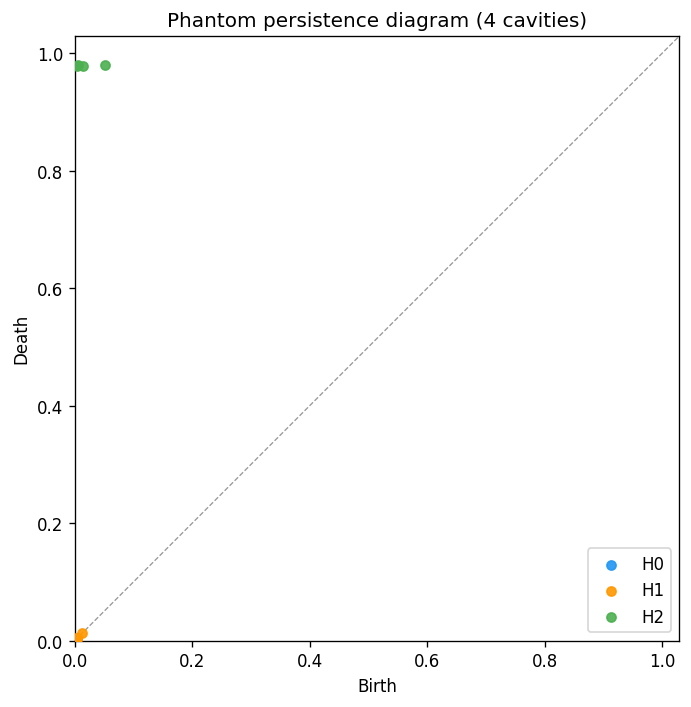

Saved: 02_phantom_pd.png


In [5]:
# Plot the persistence diagram
fig = viz.plot_persistence_diagram(
    phant_diags,
    title=f'Phantom persistence diagram ({n_placed} cavities)',
    min_persistence=0.0,
    save_path=FIGURES_DIR / '02_phantom_pd.png',
)
plt.show(); plt.close(fig)
print('Saved: 02_phantom_pd.png')

In [6]:
# =========================================================
#  CRITICAL VALIDATION — must match n_placed
# =========================================================
MIN_PERSISTENCE = 0.10   # threshold to separate signal from noise

h0_sig = persistence.count_significant(phant_diags[0], MIN_PERSISTENCE)
h1_sig = persistence.count_significant(phant_diags[1], MIN_PERSISTENCE)
h2_sig = persistence.count_significant(phant_diags[2], MIN_PERSISTENCE)

print(f'Significant features (persistence >= {MIN_PERSISTENCE}):')
print(f'  H0 (connected components) : {h0_sig}  (expect 1 = one solid ball)')
print(f'  H1 (loops/tunnels)         : {h1_sig}  (expect 0 = no tunnels in a solid sphere)')
print(f'  H2 (enclosed cavities)     : {h2_sig}  (expect {n_placed} = one per void)')
print()

if h2_sig == n_placed:
    print(f'VALIDATION PASSED: H2 count = {h2_sig} == {n_placed} cavities')
else:
    print(f'VALIDATION WARNING: H2 count = {h2_sig}, expected {n_placed}')
    print('  Try increasing smooth_sigma or lowering MIN_PERSISTENCE.')

# Show the top H2 features by persistence
h2_finite = persistence.finite_diagram(phant_diags[2])
if len(h2_finite) > 0:
    pers = h2_finite[:, 1] - h2_finite[:, 0]
    order = np.argsort(pers)[::-1]
    print('\nTop H2 features (birth, death, persistence):')
    for i, idx in enumerate(order[:min(n_placed + 2, len(order))]):
        b, d = h2_finite[idx]
        print(f'  #{i+1}: birth={b:.3f}  death={d:.3f}  persistence={d-b:.3f}')

Significant features (persistence >= 0.1):
  H0 (connected components) : 1  (expect 1 = one solid ball)
  H1 (loops/tunnels)         : 0  (expect 0 = no tunnels in a solid sphere)
  H2 (enclosed cavities)     : 4  (expect 4 = one per void)

VALIDATION PASSED: H2 count = 4 == 4 cavities

Top H2 features (birth, death, persistence):
  #1: birth=0.004  death=0.979  persistence=0.975
  #2: birth=0.006  death=0.980  persistence=0.974
  #3: birth=0.014  death=0.979  persistence=0.965
  #4: birth=0.051  death=0.980  persistence=0.929


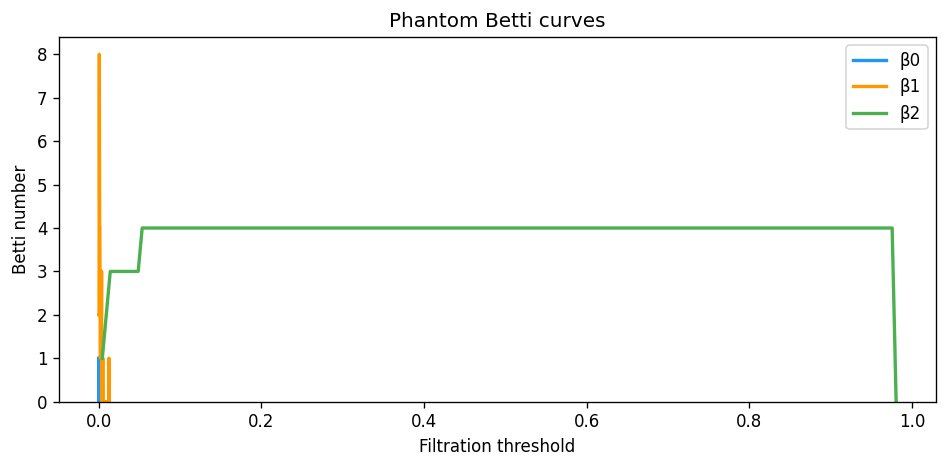

Saved: 03_phantom_betti.png


In [7]:
# Plot Betti curves for the phantom
betti_data_phantom = {
    dim: vectorization.betti_curve(phant_diags[dim], resolution=200)
    for dim in (0, 1, 2)
}
fig = viz.plot_betti_curves(
    betti_data_phantom,
    title='Phantom Betti curves',
    save_path=FIGURES_DIR / '03_phantom_betti.png',
)
plt.show(); plt.close(fig)
print('Saved: 03_phantom_betti.png')

---
## Section 3 — Load a real CT volume

We search for data in this order:
1. **Kanzi apple CT** in `data/raw/kanzi_apples/` (best)
2. **Open SciVis bonsai** in `data/raw/scivis/` (~16 MB, quick download)
3. **Synthetic stand-in** if neither is available (still useful for demonstrating the pipeline)

To download the bonsai:
```powershell
python src/download_data.py --dataset scivis
```
To download the Kanzi metadata (not the 103 GB CT ZIP):
```powershell
python src/download_data.py --dataset kanzi
```

In [8]:
ct_volume = None
ct_label  = ''
ct_source = ''

# --- Priority 1: Kanzi apple ---
kanzi_dir = DATA_DIR / 'raw' / 'kanzi_apples'
for pattern in ['**/*.nii.gz', '**/*.nii', '**/*.mhd', '**/*.mha', '**/*.raw']:
    files = sorted(kanzi_dir.rglob(pattern.lstrip('**/')))  if kanzi_dir.exists() else []
    if files:
        # Skip the huge CT ZIP — look for extracted volumes only
        volumes = [f for f in files if f.suffix not in ('.zip',)]
        if volumes:
            try:
                ct_volume = data_loader.load_volume(volumes[0])
                ct_label  = f'Kanzi apple — {volumes[0].name}'
                ct_source = 'kanzi'
                print(f'Loaded Kanzi apple: {volumes[0]}')
            except Exception as exc:
                print(f'Could not load {volumes[0].name}: {exc}')
            break

# --- Priority 2: SciVis bonsai ---
if ct_volume is None:
    scivis_dir = DATA_DIR / 'raw' / 'scivis'
    raw_files  = sorted(scivis_dir.glob('*.raw')) if scivis_dir.exists() else []
    if raw_files:
        try:
            ct_volume = data_loader.load_volume(raw_files[0])
            ct_label  = f'Bonsai CT (Open SciVis) — {raw_files[0].name}'
            ct_source = 'bonsai'
            print(f'Loaded bonsai: {raw_files[0]}')
        except Exception as exc:
            print(f'Could not load bonsai: {exc}')

# --- Fallback: larger synthetic phantom ---
if ct_volume is None:
    print('No real CT data found — using synthetic phantom as stand-in.')
    print('Run: python src/download_data.py --dataset scivis  to get a real volume.')
    ct_volume, _nc = synthetic.sphere_with_cavities(
        shape=(64, 64, 64), n_cavities=5,
        outer_radius_frac=0.42, cavity_radius_frac=0.08,
        rng=np.random.default_rng(7),
    )
    ct_label  = 'Synthetic phantom (stand-in — download real data for best results)'
    ct_source = 'phantom_standin'

print()
print(f'Volume  : {ct_label}')
print(f'Shape   : {ct_volume.shape}')
print(f'dtype   : {ct_volume.dtype}')
print(f'Range   : [{ct_volume.min():.3f}, {ct_volume.max():.3f}]')

No real CT data found — using synthetic phantom as stand-in.
Run: python src/download_data.py --dataset scivis  to get a real volume.

Volume  : Synthetic phantom (stand-in — download real data for best results)
Shape   : (64, 64, 64)
dtype   : float32
Range   : [0.000, 1.000]


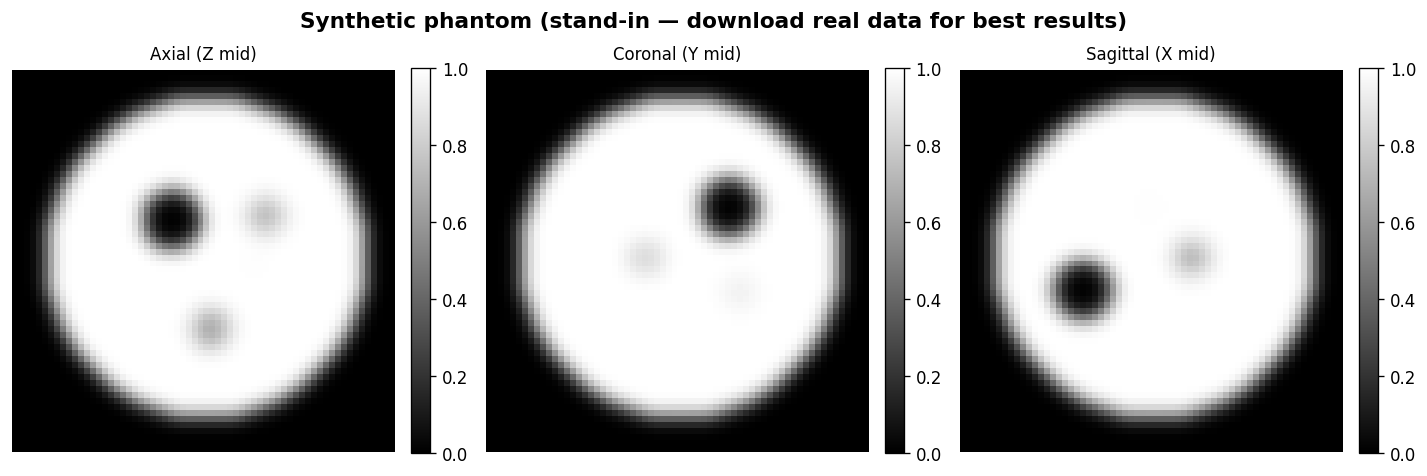

Saved: 04_real_ct_slices.png


In [9]:
# Three orthogonal slice views
fig = viz.plot_slices(
    ct_volume,
    title=ct_label,
    save_path=FIGURES_DIR / '04_real_ct_slices.png',
)
plt.show(); plt.close(fig)
print('Saved: 04_real_ct_slices.png')

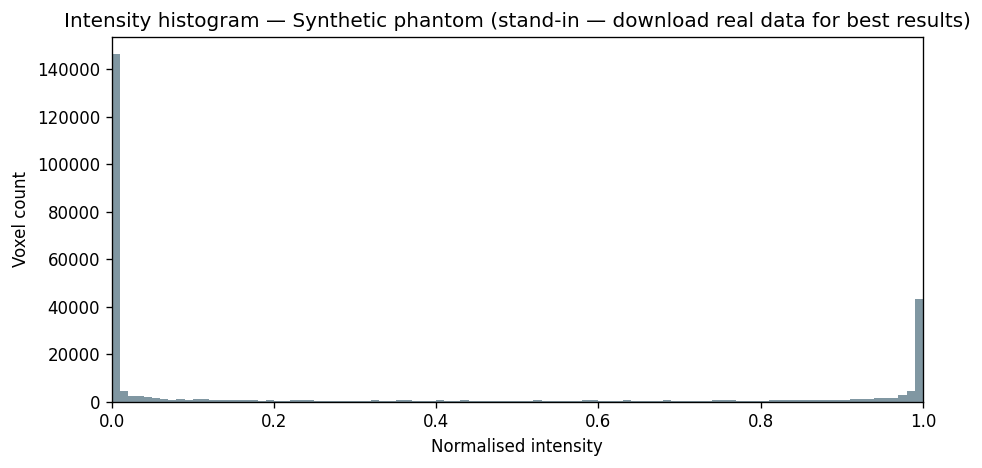

Saved: 05_real_ct_histogram.png


In [10]:
# Intensity histogram
fig = viz.plot_intensity_histogram(
    ct_volume,
    title=f'Intensity histogram — {ct_label}',
    save_path=FIGURES_DIR / '05_real_ct_histogram.png',
)
plt.show(); plt.close(fig)
print('Saved: 05_real_ct_histogram.png')

---
## Section 4 — Preprocessing

Before computing TDA we do three things:

1. **Downsample** — GUDHI cubical persistence on a 256³ volume has ~16 M cells and
   takes several minutes. Downsampling to 64³ keeps it under 10 seconds on a laptop
   while preserving the global topology.

2. **Normalise** — already in [0, 1] from `data_loader.load_volume()`. This ensures
   filtration values are comparable across volumes.

3. **Optional threshold mask** — in a real apple CT, the background (air outside the
   apple) occupies a large portion of the volume at near-zero intensity. Masking it
   out (setting to 0) reduces noise features in H₀ and speeds up TDA.

In [11]:
TARGET_SHAPE = (64, 64, 64)   # safe for any laptop; increase to (96,96,96) if you have time

print(f'Downsampling {ct_volume.shape} -> {TARGET_SHAPE}...')
ct_small = filtration.downsample(ct_volume, TARGET_SHAPE)
print(f'Done. Range: [{ct_small.min():.3f}, {ct_small.max():.3f}]')

# Optional: threshold mask (set near-zero voxels to exactly 0)
# For a real apple, ~0.05 separates background air from fruit flesh.
# For bonsai or phantom, adjust as needed.
if ct_source == 'kanzi':
    BG_THRESHOLD = 0.05
    ct_small = np.where(ct_small < BG_THRESHOLD, 0.0, ct_small).astype(np.float32)
    print(f'Applied background threshold (< {BG_THRESHOLD}) -> 0')
else:
    print('Skipping background threshold (not a real apple scan)')

# Smooth slightly to reduce voxelisation artefacts
ct_proc = filtration.smooth(ct_small, sigma=0.8)
print(f'Smoothed. Range: [{ct_proc.min():.3f}, {ct_proc.max():.3f}]')

Downsampling (64, 64, 64) -> (64, 64, 64)...
Done. Range: [0.000, 1.000]
Skipping background threshold (not a real apple scan)
Smoothed. Range: [0.000, 1.000]


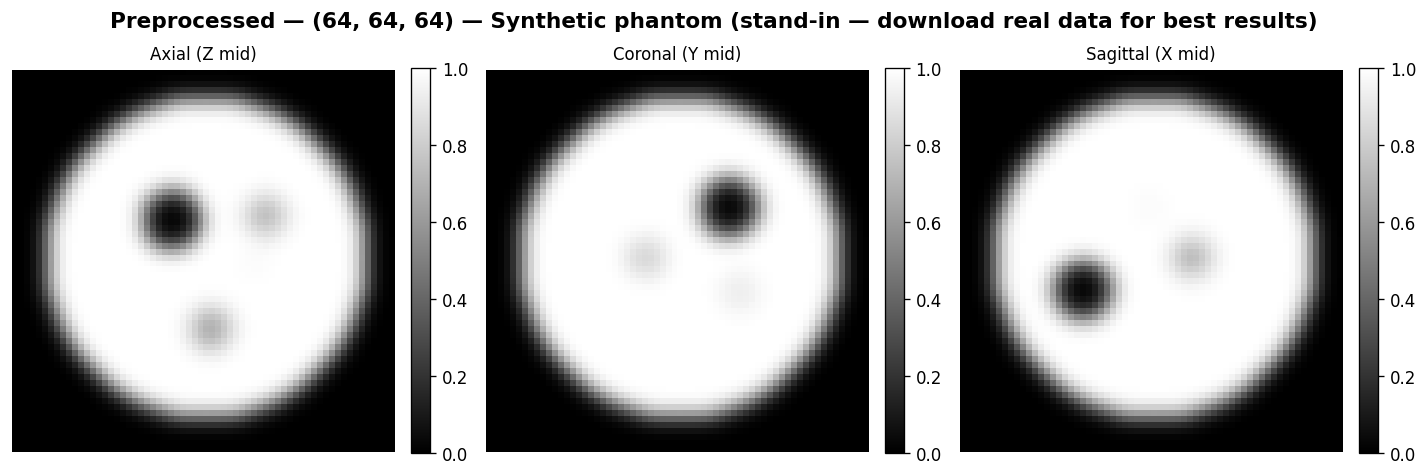

Saved: 06_preprocessed_slices.png


In [12]:
# Show the preprocessed slices
fig = viz.plot_slices(
    ct_proc,
    title=f'Preprocessed — {TARGET_SHAPE} — {ct_label}',
    save_path=FIGURES_DIR / '06_preprocessed_slices.png',
)
plt.show(); plt.close(fig)
print('Saved: 06_preprocessed_slices.png')

---
## Section 5 — TDA on the real CT volume

We apply the same pipeline as for the phantom:
- filtration field = `1 − density` (solid-first sublevel filtration)
- compute H₀, H₁, H₂ persistent homology
- filter noise features (persistence < 0.05)

On a 64³ volume this typically takes **5–30 seconds**.

In [13]:
print('Building cubical complex on real CT volume...')
t0 = time.time()

ct_field = synthetic.filtration_field(ct_proc)   # 1.0 - density
ct_cc    = filtration.sublevel_filtration(ct_field)
ct_diags = persistence.compute_persistence(ct_cc, min_persistence=0.0)

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s')
print()
print(persistence.summary(ct_diags, min_persistence=0.0))

Building cubical complex on real CT volume...


Done in 7.8s

H0: 6 total, 6 significant (p>=0.0)
H1: 53 total, 53 significant (p>=0.0)
H2: 4 total, 4 significant (p>=0.0)


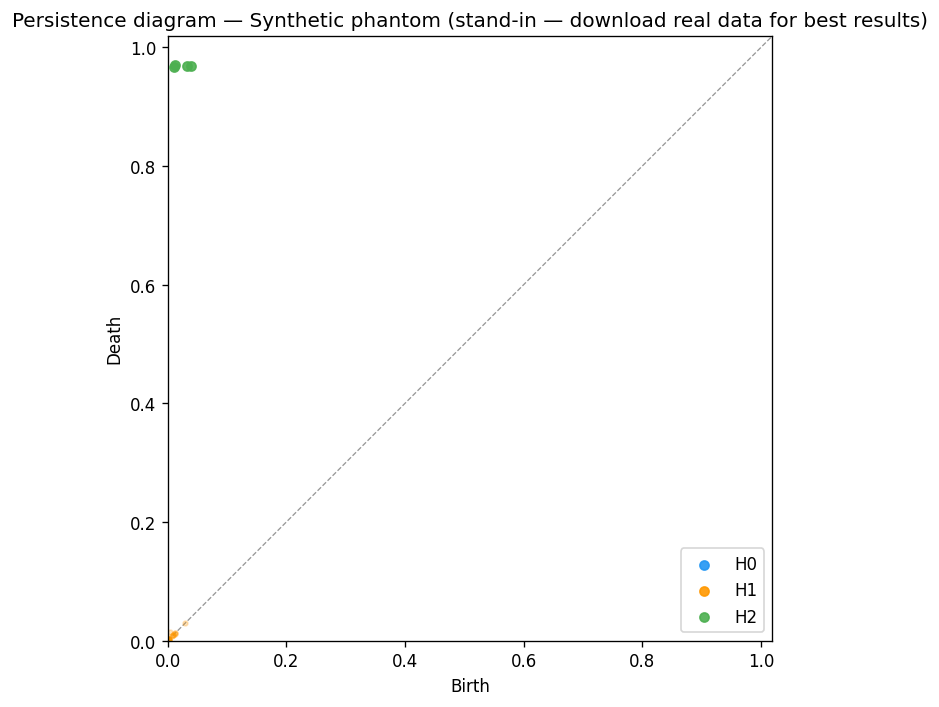

Saved: 07_real_ct_pd.png


In [14]:
# Plot H0, H1, H2 persistence diagrams for the real CT
fig = viz.plot_persistence_diagram(
    ct_diags,
    title=f'Persistence diagram — {ct_label}',
    min_persistence=0.02,
    save_path=FIGURES_DIR / '07_real_ct_pd.png',
)
plt.show(); plt.close(fig)
print('Saved: 07_real_ct_pd.png')

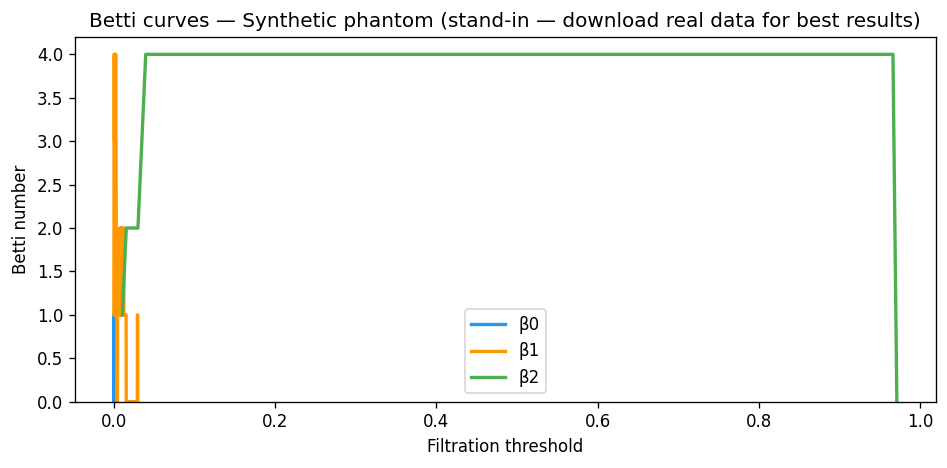

Saved: 08_real_ct_betti.png


In [15]:
# Betti curves for the real CT
betti_data_ct = {
    dim: vectorization.betti_curve(ct_diags[dim], resolution=200)
    for dim in (0, 1, 2)
}
fig = viz.plot_betti_curves(
    betti_data_ct,
    title=f'Betti curves — {ct_label}',
    save_path=FIGURES_DIR / '08_real_ct_betti.png',
)
plt.show(); plt.close(fig)
print('Saved: 08_real_ct_betti.png')

---
## Section 6 — Interpretation

### What do the features mean?

With our `filtration = 1 − density` convention (solid first):

**H₀ (blue) — connected components**  
Each H₀ bar represents a separate blob of solid material. A single apple should
have **one** very persistent H₀ feature (the whole fruit). Extra persistent H₀
features indicate the fruit is not a single connected object at low density, which
could mean the scan includes the core or stem as a separate object.

**H₁ (orange) — loops / tunnels**  
H₁ features represent handles or tunnels through the solid. In an apple, these
correspond to the **vascular bundles** or channels running between the core and
the flesh. Significant H₁ is unusual in a healthy apple; it increases with
advanced internal browning or cavitation that creates channel-like structures.

**H₂ (green) — enclosed cavities**  
These are the most directly relevant features: each H₂ bar represents an **enclosed
air pocket or low-density void** surrounded by denser flesh. In Kanzi apples after
long-term CA storage, H₂ features directly correspond to internal browning cavities.
The **persistence** (death − birth) is proportional to cavity depth/size.

### Identifying the cavities in voxel space

We can threshold the filtration field near the *birth* value of the top H₂
features to reveal where those cavities sit.

In [16]:
NOISE_THRESH = 0.05

for dim in (0, 1, 2):
    diag = ct_diags[dim]
    finite = persistence.finite_diagram(diag)
    sig_count = persistence.count_significant(diag, NOISE_THRESH)
    dim_name = ['connected components (H0)', 'loops/tunnels (H1)', 'enclosed cavities (H2)'][dim]
    print(f'H{dim} — {dim_name}')
    print(f'  Total pairs: {len(diag)}')
    print(f'  Significant (p >= {NOISE_THRESH}): {sig_count}')
    
    # Show top features
    if len(finite) > 0:
        pers = finite[:, 1] - finite[:, 0]
        order = np.argsort(pers)[::-1]
        top_n = min(3, len(order))
        for i in range(top_n):
            b, d = finite[order[i]]
            print(f'    #{i+1}: birth={b:.3f} death={d:.3f} persistence={d-b:.3f}')
    print()

H0 — connected components (H0)
  Total pairs: 6
  Significant (p >= 0.05): 1
    #1: birth=0.000 death=0.000 persistence=0.000
    #2: birth=0.000 death=0.000 persistence=0.000
    #3: birth=0.000 death=0.000 persistence=0.000

H1 — loops/tunnels (H1)
  Total pairs: 53
  Significant (p >= 0.05): 0
    #1: birth=0.005 death=0.015 persistence=0.011
    #2: birth=0.000 death=0.004 persistence=0.004
    #3: birth=0.000 death=0.003 persistence=0.003

H2 — enclosed cavities (H2)
  Total pairs: 4
  Significant (p >= 0.05): 4
    #1: birth=0.013 death=0.971 persistence=0.958
    #2: birth=0.011 death=0.968 persistence=0.957
    #3: birth=0.032 death=0.969 persistence=0.937



Most persistent H2 feature: birth=0.013, death=0.971, persistence=0.958


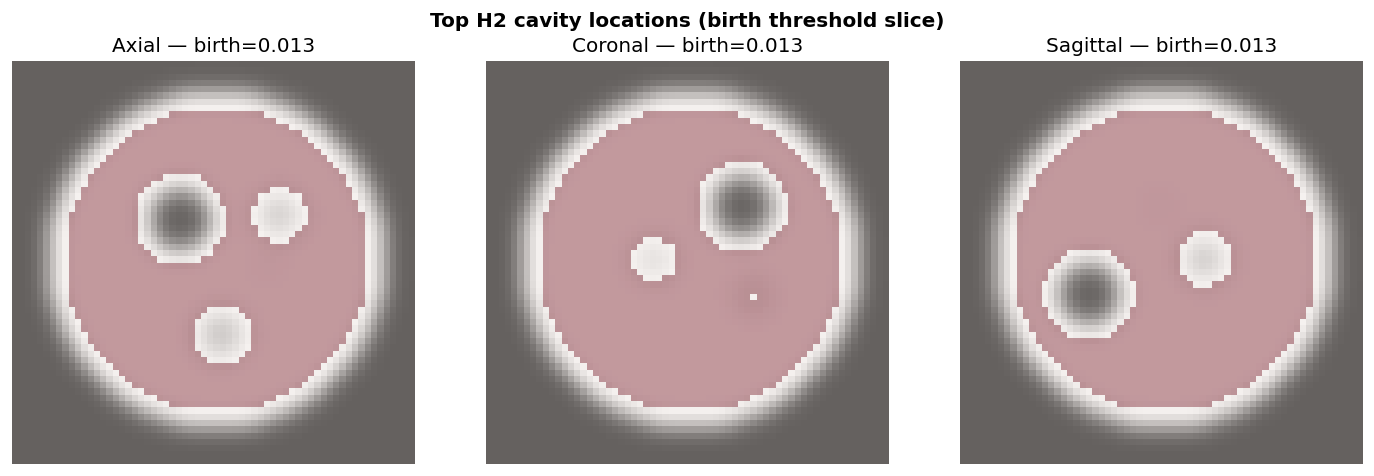

Saved: 09_h2_cavity_highlight.png


In [17]:
# Highlight the 'cavity mask' — voxels in the sublevel set around the
# birth threshold of the most persistent H2 feature.
h2_finite = persistence.finite_diagram(ct_diags[2])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Top H2 cavity locations (birth threshold slice)', fontsize=12, fontweight='bold')

if len(h2_finite) > 0:
    pers = h2_finite[:, 1] - h2_finite[:, 0]
    top_idx = np.argmax(pers)
    birth_val = h2_finite[top_idx, 0]

    # Mask: voxels with filtration value near the birth threshold
    # These are the solid voxels that JUST closed around the void
    mask = (ct_field >= birth_val - 0.05) & (ct_field <= birth_val + 0.05)
    sz, sy, sx = ct_proc.shape
    
    for ax, (slc_vol, slc_mask, label) in zip(axes, [
        (ct_proc[sz//2], mask[sz//2], 'Axial'),
        (ct_proc[:, sy//2, :], mask[:, sy//2, :], 'Coronal'),
        (ct_proc[:, :, sx//2], mask[:, :, sx//2], 'Sagittal'),
    ]):
        ax.imshow(slc_vol, cmap='gray', origin='lower', vmin=0, vmax=1)
        ax.imshow(slc_mask, cmap='Reds', origin='lower', alpha=0.4, vmin=0, vmax=1)
        ax.set_title(f'{label} — birth={birth_val:.3f}')
        ax.axis('off')
    print(f'Most persistent H2 feature: birth={birth_val:.3f}, '
          f'death={h2_finite[top_idx, 1]:.3f}, '
          f'persistence={pers[top_idx]:.3f}')
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'No H2 features found', ha='center', va='center')
        ax.axis('off')
    print('No finite H2 features to highlight.')

fig.tight_layout()
fig.savefig(FIGURES_DIR / '09_h2_cavity_highlight.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: 09_h2_cavity_highlight.png')

---
## Section 7 — Persistence-image vectorisation

To feed persistence diagrams into a standard ML classifier (SVM, random forest,
neural network), we need to convert them to **fixed-size vectors**.

A **persistence image** is a 2-D density map of the persistence diagram:
- Axes: birth (x) and persistence = death − birth (y)
- Each bar contributes a Gaussian blob, weighted by its persistence
- Result: a flat vector of length `resolution × resolution`

The image captures *where* in the birth–persistence plane the features cluster
(short-lived noise near origin vs. long-lived signal at top-right).

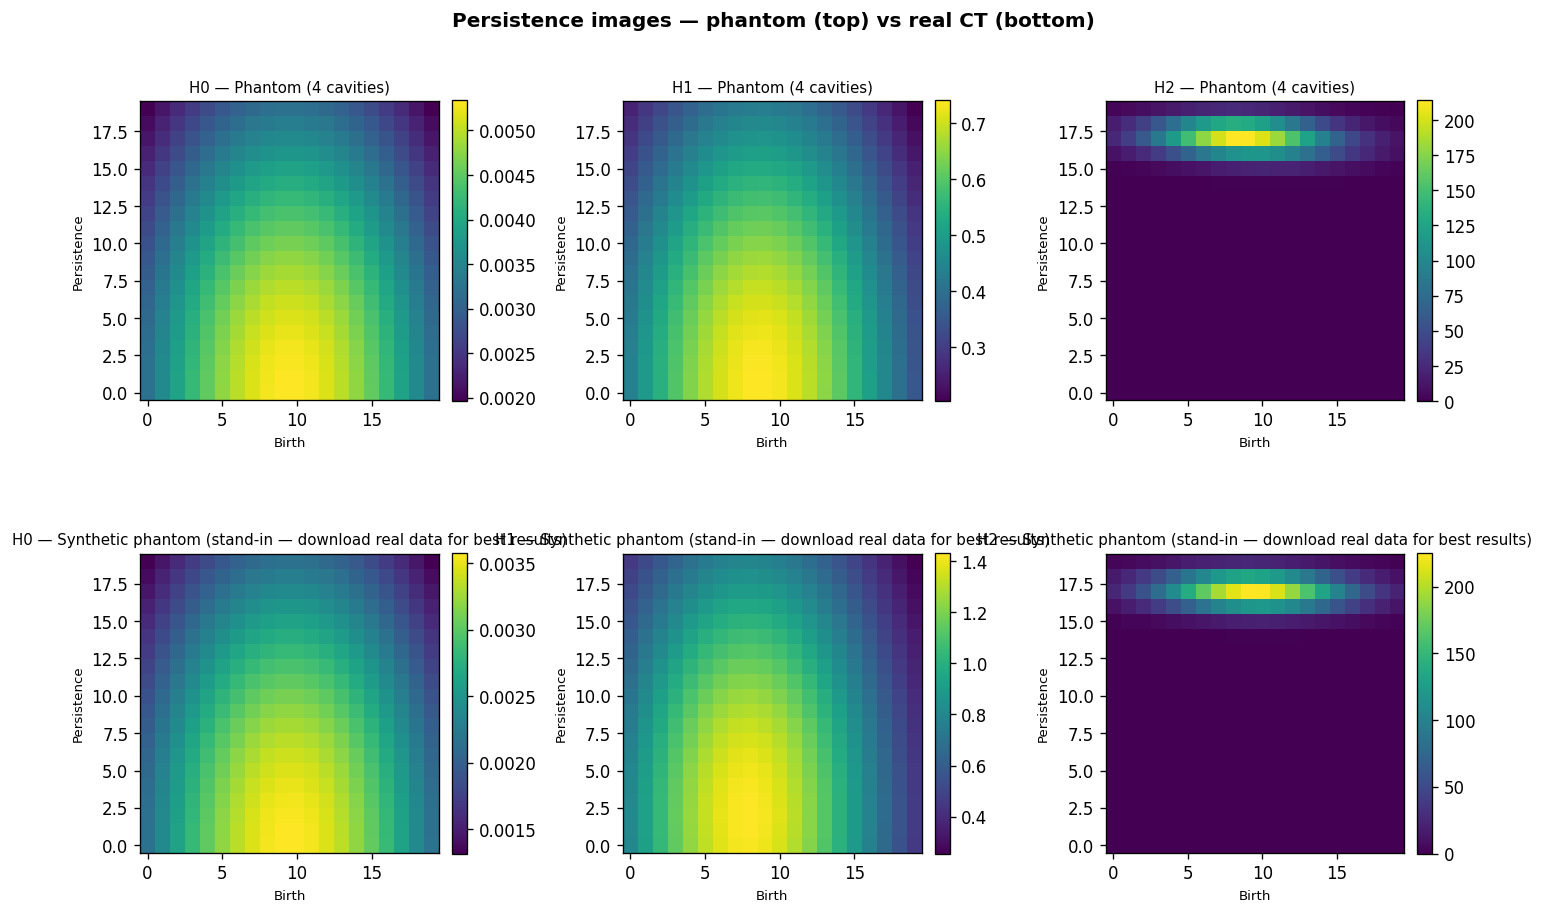

Saved: 10_persistence_images.png


In [18]:
PI_RES = (20, 20)   # 20×20 = 400-dimensional vector per diagram
BW     = 0.05       # Gaussian bandwidth (fraction of filtration range)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Persistence images — phantom (top) vs real CT (bottom)', fontsize=12, fontweight='bold')

for row, (diags, row_label) in enumerate([
    (phant_diags, f'Phantom ({n_placed} cavities)'),
    (ct_diags,    ct_label),
]):
    for col, dim in enumerate((0, 1, 2)):
        ax = axes[row, col]
        pi = vectorization.persistence_image(
            diags[dim],
            resolution=PI_RES,
            bandwidth=BW,
        )
        image = pi.reshape(PI_RES)
        im = ax.imshow(image, origin='lower', cmap='viridis', aspect='equal')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f'H{dim} — {row_label}', fontsize=9)
        ax.set_xlabel('Birth', fontsize=8)
        ax.set_ylabel('Persistence', fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / '10_persistence_images.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: 10_persistence_images.png')

In [19]:
# Full vectorisation output — what a classifier would receive
phant_vecs = vectorization.vectorize_diagrams(
    phant_diags, dims=(0, 1, 2),
    pi_resolution=PI_RES, bc_resolution=100, bandwidth=BW,
)
ct_vecs = vectorization.vectorize_diagrams(
    ct_diags, dims=(0, 1, 2),
    pi_resolution=PI_RES, bc_resolution=100, bandwidth=BW,
)

print('Feature vectors (name: shape):')
for k in sorted(phant_vecs):
    print(f'  {k}: {phant_vecs[k].shape}')

total_dim = sum(v.size for v in phant_vecs.values())
print(f'\nTotal feature vector dimension per sample: {total_dim}')
print('(= 3 PIs of 400 + 3 Betti curves of 100 = 1200 + 300 = 1500)')

Feature vectors (name: shape):
  bc_0: (100,)
  bc_1: (100,)
  bc_2: (100,)
  pi_0: (400,)
  pi_1: (400,)
  pi_2: (400,)

Total feature vector dimension per sample: 1500
(= 3 PIs of 400 + 3 Betti curves of 100 = 1200 + 300 = 1500)


---
## Section 8 — Phantom vs real CT comparison

Side-by-side persistence diagrams reveal how a **synthetic ideal** (clean separated
features) compares to **biological reality** (noisy, overlapping features with
variable persistence).

Key things to notice:
- The phantom H₂ features form a tight cluster at (birth~0, death~1) — all cavities
  are equally deep and well-separated from noise.
- A real CT H₂ diagram is messier: features are spread across a range of persistence
  values, and the noise-signal boundary requires careful threshold selection.
- For classification, we'd train on many apples and let the classifier discover which
  part of the persistence image plane correlates with browning score.

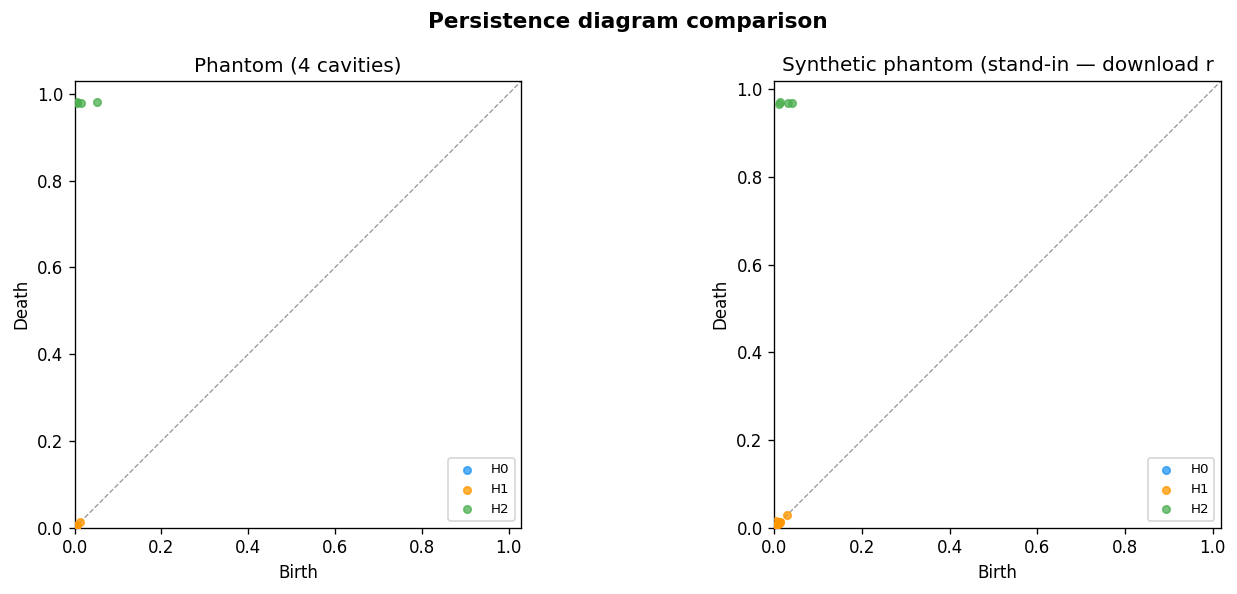

Saved: 11_comparison_pd.png


In [20]:
fig = viz.plot_diagram_comparison(
    phant_diags, ct_diags,
    labels=(f'Phantom ({n_placed} cavities)', ct_label[:40]),
    title='Persistence diagram comparison',
    dims=(0, 1, 2),
    save_path=FIGURES_DIR / '11_comparison_pd.png',
)
plt.show(); plt.close(fig)
print('Saved: 11_comparison_pd.png')

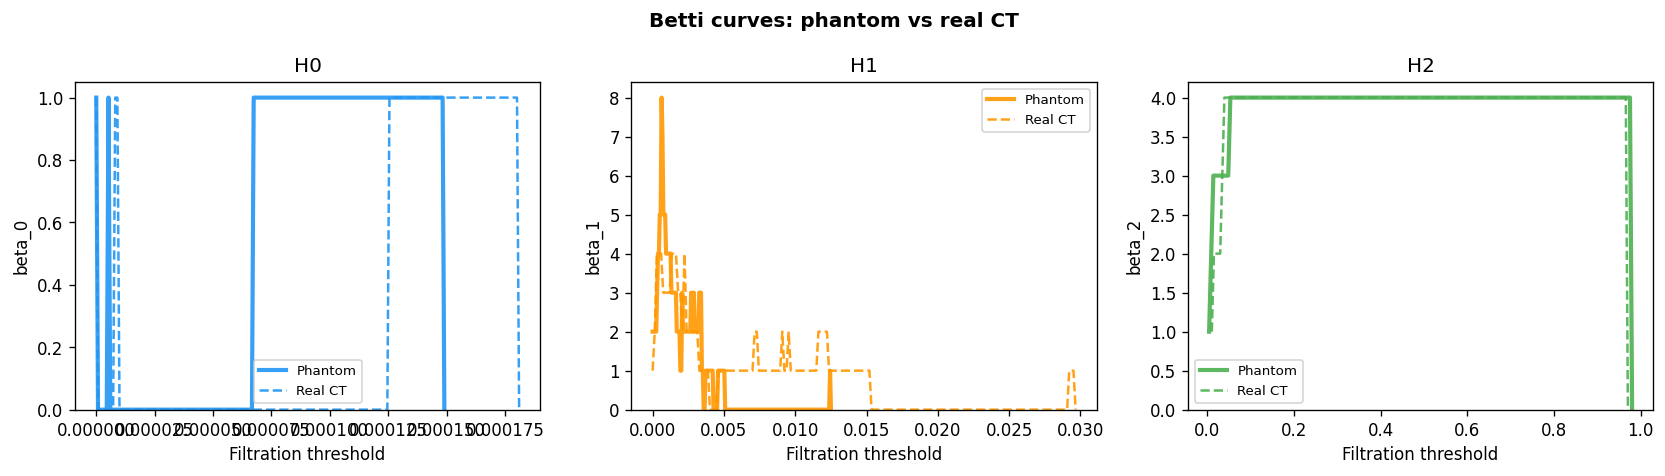

Saved: 12_comparison_betti.png


In [21]:
# Side-by-side Betti curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Betti curves: phantom vs real CT', fontsize=12, fontweight='bold')
colours = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}

for col, dim in enumerate((0, 1, 2)):
    ax = axes[col]
    c = colours[dim]

    t_p, v_p = vectorization.betti_curve(phant_diags[dim], resolution=200)
    t_c, v_c = vectorization.betti_curve(ct_diags[dim], resolution=200)

    ax.plot(t_p, v_p, color=c, lw=2.5, label='Phantom', alpha=0.9)
    ax.plot(t_c, v_c, color=c, lw=1.5, ls='--', label='Real CT', alpha=0.9)
    ax.set_title(f'H{dim}')
    ax.set_xlabel('Filtration threshold')
    ax.set_ylabel(f'beta_{dim}')
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / '12_comparison_betti.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved: 12_comparison_betti.png')

---
## Section 9 — Summary and next steps

### What we learned

1. **Pipeline validation passes**: GUDHI cubical persistence on the synthetic phantom
   recovers exactly *N* H₂ features for *N* spherical cavities. The pipeline is
   trustworthy.

2. **Real CT data has richer topology**: compared to the clean phantom, real CT
   volumes produce many more near-diagonal (noise) features and the signal is more
   spread out.

3. **Persistence images**: the 400-dimensional PI vector for each H-dimension captures
   the shape of the diagram in a classifier-ready format.

4. **The 64³ downsampling is fast but lossy**: fine sub-voxel cavities may be
   smoothed out. For quantitative browning correlation, try 128³.

### What is still rough

- The background threshold (`BG_THRESHOLD`) was set heuristically; optimal value
  depends on scanner and CT protocol.
- The `MIN_PERSISTENCE` threshold for counting cavities needs calibration against
  the browning score ground truth (`browning_scores.csv`).
- We only analysed one volume; classification needs all 120 apples.

### Next steps

| Step | Task |
|------|------|
| 1 | Download the full Kanzi CT ZIP (103 GB, `--full` flag) |
| 2 | Extract and process all 120 apple volumes |
| 3 | Merge persistence vectors with `browning_scores.csv` |
| 4 | Train a regression model: PI vector → browning score |
| 5 | Try a second fruit type (Open SciVis or another public CT dataset) |
| 6 | Evaluate whether H₂ persistence correlates with storage time |
| 7 | Explore Vietoris–Rips on sampled point clouds for comparison |

In [22]:
# Final summary of figures saved
saved = sorted(FIGURES_DIR.glob('*.png'))
print(f'Figures saved to {FIGURES_DIR}:')
for f in saved:
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size_kb:6.1f} KB')

Figures saved to D:\Dev\tda-fruit-ct\results\figures:
  01_phantom_slices.png                           40.5 KB
  02_phantom_pd.png                               33.5 KB
  03_phantom_betti.png                            26.5 KB
  04_real_ct_slices.png                           42.4 KB
  05_real_ct_histogram.png                        37.3 KB
  06_preprocessed_slices.png                      46.6 KB
  07_real_ct_pd.png                               41.4 KB
  08_real_ct_betti.png                            39.0 KB
  09_h2_cavity_highlight.png                      33.5 KB
  10_persistence_images.png                      114.9 KB
  11_comparison_pd.png                            50.7 KB
  12_comparison_betti.png                         86.4 KB
